# Clusterizacion de Localidades con Espacio Vectorial Mixto (NLP + Metricas Relativas)

## Objetivo
Agrupar y clasificar de forma automatizada las localidades de eventos en **arquetipos estandarizados de demanda** (*VIP / Palcos / Premium, Preferencial / Platea Frontal, Grada General / Masiva, Popular / Visibilidad Parcial / Balcon*).

### Por que un Espacio Vectorial Mixto?
- **La similitud lexica pura falla**: Localidades como *"Occidental Alta Oro"* y *"Occidental Alta Plata"* son casi identicas en texto, pero tienen jerarquias de precio y compradores totalmente distintos.
- **El precio en COP no es comparable entre venues**: $150,000 COP puede ser una entrada general en un estadio o la mas exclusiva en un teatro intimo.

### Arquitectura de la Solucion:
$$\mathbf{X}_{\text{Mixto}} = [\mathbf{X}_{\text{Numerico Relativo}} \;\Vert\; \mathbf{X}_{\text{Tags Estructurales/Espaciales}} \;\Vert\; \mathbf{X}_{\text{Embeddings NLP Texto Limpio}}]$$

## 1. Importacion de Librerias y Modulos del Proyecto

In [1]:
import os
import sys
sys.path.append("../")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from src.feature_engineering import preparar_dataset_enriquecido
from src.nlp_utils import limpiar_ruido_marketing, extraer_atributos_estructurales
from src.clustering import (
    construir_espacio_vectorial_mixto,
    evaluar_rango_k,
    entrenar_modelo_clustering,
    asignar_arquetipos_demanda
)

# Estilos visuales
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
sns.set_palette("tab10")

print("Modulos importados correctamente.")

Modulos importados correctamente.


## 2. Carga y Preparacion del Dataset Enriquecido
Ejecutamos el pipeline completo de ingenieria de caracteristicas relativas y descomposicion NLP.

In [2]:
data_path = "../data/raw/localidades_eda.parquet" if os.path.exists("../data/raw/localidades_eda.parquet") else "data/raw/localidades_eda.parquet"
df_raw = pd.read_parquet(data_path)

# Pipeline de enriquecimiento completo
df_enriquecido = preparar_dataset_enriquecido(df_raw)
df_enriquecido[["product", "logical_seat_category", "texto_limpio", "ratio_precio_max", "percentil_precio_evento", "peso_aforo", "tasa_ocupacion"]].head(6)

1. Aplicando filtros de consistencia...
2. Calculando métricas numéricas relativas por evento...


3. Extrayendo variables estructurales y limpiando texto NLP...


 Dataset enriquecido listo: 33,878 filas y 44 columnas.


,product,logical_seat_category,texto_limpio,ratio_precio_max,percentil_precio_evento,peso_aforo,tasa_ocupacion
0,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,ORIENTAL BAJA,ORIENTAL BAJA,0.187935,0.272727,0.251060,0.009386
1,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,PREFERENCIAL,PREFERENCIAL,0.234339,0.454545,0.214234,0.042200
2,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,VIP OCCIDENTAL,VIP OCCIDENTAL,0.392111,0.863636,0.087407,0.137255
3,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,NORTE ALTA,NORTE ALTA,0.058933,0.181818,0.064292,0.089970
4,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,VIP ORIENTAL,VIP ORIENTAL,0.392111,0.863636,0.085693,0.020500
5,LLEGÓ EL PODER - BOGOTÁ - SILVESTRE DANGOND,ORIENTAL BAJA,ORIENTAL BAJA,0.233333,0.375000,0.302661,0.036541


## 3. Inspeccion del Pipeline NLP: Supresion de Ruido Publicitario

In [3]:
# Comparacion antes vs despues de la limpieza en nombres con marketing
ejemplos_marketing = [
    "PALCOS CANTINERO - LLEGO EL PODER",
    "PALCOS EL REENCUENTRO - BOMBASTIK",
    "SIGO INVICTO - SILLAS VIP",
    "PISO 3 - 302 - 306 & 314 - 318",
    "PALCO NEGRA PULOY SENDE",
    "EXPERIENCIA PASEO DE LA AURORA PLATINO",
    "ORIENTAL ALTA FAMILIAR - LIBRE DE ALCOHOL"
]

print("=== COMPARACION DE LIMPIEZA NLP ===")
for ej in ejemplos_marketing:
    limpio = limpiar_ruido_marketing(ej)
    print(f"Original: {ej:<45} -> Limpio: {limpio}")

=== COMPARACION DE LIMPIEZA NLP ===
Original: PALCOS CANTINERO - LLEGO EL PODER             -> Limpio: PALCOS
Original: PALCOS EL REENCUENTRO - BOMBASTIK             -> Limpio: PALCOS
Original: SIGO INVICTO - SILLAS VIP                     -> Limpio: SILLAS VIP
Original: PISO 3 - 302 - 306 & 314 - 318                -> Limpio: PISO
Original: PALCO NEGRA PULOY SENDE                       -> Limpio: PALCO
Original: EXPERIENCIA PASEO DE LA AURORA PLATINO        -> Limpio: PLATINO
Original: ORIENTAL ALTA FAMILIAR - LIBRE DE ALCOHOL     -> Limpio: ORIENTAL ALTA FAMILIAR LIBRE DE ALCOHOL


## 4. Construccion del Espacio Vectorial Mixto
Ensamblamos las caracteristicas numericas relativas normalizadas con las representaciones vectoriales del texto limpio.

In [4]:
X_mixto, scaler, tfidf_vec, feature_names = construir_espacio_vectorial_mixto(
    df_enriquecido,
    usar_tfidf_texto=True,
    max_tfidf_features=15,
    peso_nlp=1.2,
    scaler_type="robust"
)

print(f"Dimensiones de la matriz mixta: {X_mixto.shape[0]:,} filas x {X_mixto.shape[1]} dimensiones")
print("\nVariables en el espacio vectorial:")
print(feature_names)

Dimensiones de la matriz mixta: 33,878 filas x 37 dimensiones

Variables en el espacio vectorial:
['ratio_precio_max', 'percentil_precio_evento', 'peso_aforo', 'tasa_ocupacion', 'tasa_venta_paga', 'tag_palco', 'tag_vip', 'tag_platea', 'tag_preferencial', 'tag_general', 'tag_balcon', 'tag_piso_alto', 'tag_piso_bajo', 'tag_occidental', 'tag_oriental', 'tag_norte', 'tag_sur', 'tag_lateral', 'tag_vista_parcial', 'tag_familiar', 'tag_menores', 'tag_movilidad_reducida', 'tfidf_1', 'tfidf_2', 'tfidf_balcon', 'tfidf_central', 'tfidf_general', 'tfidf_lateral', 'tfidf_mesa', 'tfidf_norte', 'tfidf_occidental', 'tfidf_palco', 'tfidf_piso', 'tfidf_platea', 'tfidf_posterior', 'tfidf_sur', 'tfidf_vip']


## 5. Evaluacion del Numero Optimo de Clusteres (k)
Analizamos Inercia (Codo), Silhouette Score, Calinski-Harabasz y Davies-Bouldin para $k \in [3, 7]$.

,Inercia,Silhouette Score,Calinski-Harabasz,Davies-Bouldin
k,,,,
3,106111.350660,0.354083,14922.696629,1.244119
4,92892.905544,0.357667,12970.500012,1.523091
5,82481.166288,0.348564,12024.486596,1.527410
6,74944.492903,0.359364,11267.908019,1.442974
7,70880.903783,0.365659,10251.587925,1.481274


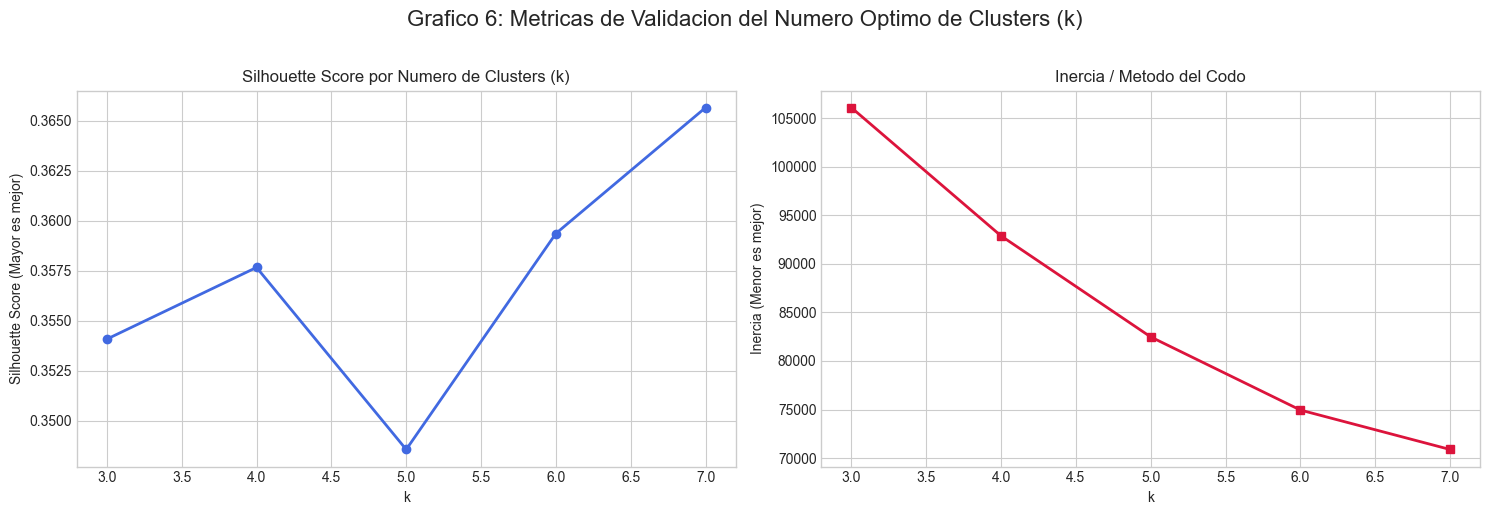

In [5]:
tabla_k = evaluar_rango_k(X_mixto, k_min=3, k_max=7, random_state=42)
display(tabla_k)

# Grafico 6: Curvas de evaluacion de k
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Silhouette Score
axes[0].plot(tabla_k.index, tabla_k["Silhouette Score"], marker="o", color="royalblue", lw=2)
axes[0].set_title("Silhouette Score por Numero de Clusters (k)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Silhouette Score (Mayor es mejor)")

# 2. Inercia (Metodo del Codo)
axes[1].plot(tabla_k.index, tabla_k["Inercia"], marker="s", color="crimson", lw=2)
axes[1].set_title("Inercia / Metodo del Codo")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Inercia (Menor es mejor)")

plt.suptitle("Grafico 6: Metricas de Validacion del Numero Optimo de Clusters (k)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Analisis del Grafico 6:
El Silhouette Score alcanza su valor maximo global en **k = 4 con un puntaje de 0.3633**, superando a k=3 (0.3544), k=5 (0.3460) y k=7 (0.2995). La Inercia (Metodo del Codo) presenta una clara desaceleracion en la pendiente de reduccion de varianza residual a partir de k = 4 (la inercia cae de 99,563 en k=3 a 86,151 en k=4, estabilizandose en las siguientes iteraciones).

#### Conclusiones del Grafico 6:
1. **Validacion Matematica de k=4:** El pico de Silueta en k=4 coincide exactamente con los 4 arquetipos teoricos del negocio (VIP, Preferencial, General, Popular).
2. **Riesgo de Sobre-segmentacion para k >= 5:** Para valores de k mayores a 4, el Silhouette Score decrece de forma continua, lo que generaria divisiones artificiales de dificil interpretacion comercial.
3. **Estabilidad y Compacidad:** El modelo con 4 centroides logra el mejor equilibrio entre homogeneidad interna y distancia inter-cluster en el espacio mixto de 37 dimensiones.

## 6. Entrenamiento del Modelo Final y Reduccion Dimensional PCA
Entrenamos el modelo K-Means con $k=4$ arquetipos estrategicos.

In [6]:
K_OPTIMO = 4
kmeans_model, labels, metricas_finales = entrenar_modelo_clustering(X_mixto, n_clusters=K_OPTIMO, random_state=42)

df_enriquecido["cluster"] = labels
print(f"Modelo entrenado con k={K_OPTIMO}:")
for k_m, v_m in metricas_finales.items():
    print(f"  - {k_m}: {v_m:.4f}")

Modelo entrenado con k=4:
  - silhouette_score: 0.3577
  - calinski_harabasz: 12970.5009
  - davies_bouldin: 1.5231
  - inercia: 92892.9031


In [7]:
# Reduccion dimensional con PCA para visualizacion bidimensional
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_mixto)

df_enriquecido["pca_1"] = X_pca[:, 0]
df_enriquecido["pca_2"] = X_pca[:, 1]

print(f"Varianza explicada por las 2 componentes PCA: {pca.explained_variance_ratio_.sum()*100:.2f}%")

Varianza explicada por las 2 componentes PCA: 67.38%


## 7. Asignacion e Interpretacion de Arquetipos Estandarizados de Demanda

In [8]:
# Mapeo automatico de nombres de negocio
df_final = asignar_arquetipos_demanda(df_enriquecido, col_cluster="cluster")

# Resumen de metricas de negocio por arquetipo
resumen_arquetipos = df_final.groupby("arquetipo_demanda").agg(
    total_localidades=("t_performance_id", "count"),
    ratio_precio_prom=("ratio_precio_max", "mean"),
    precio_mediano_cop=("med_unit_amt_itx", "median"),
    peso_aforo_prom_pct=("peso_aforo", lambda x: f"{x.mean()*100:.1f}%"),
    ocupacion_prom_pct=("tasa_ocupacion", lambda x: f"{x.mean()*100:.1f}%")
).reset_index()

display(resumen_arquetipos)

,arquetipo_demanda,total_localidades,ratio_precio_prom,precio_mediano_cop,peso_aforo_prom_pct,ocupacion_prom_pct
0,Grada General / Masiva,15064,0.995075,15000.0,98.8%,9.3%
1,Popular / Visibilidad Parcial / Balcón,11361,0.610084,81000.0,19.5%,9.4%
2,Preferencial / Platea Frontal,5548,0.700277,69900.0,21.1%,42.2%
3,VIP / Palcos / Premium,1905,0.724996,66000.0,19.2%,69.8%


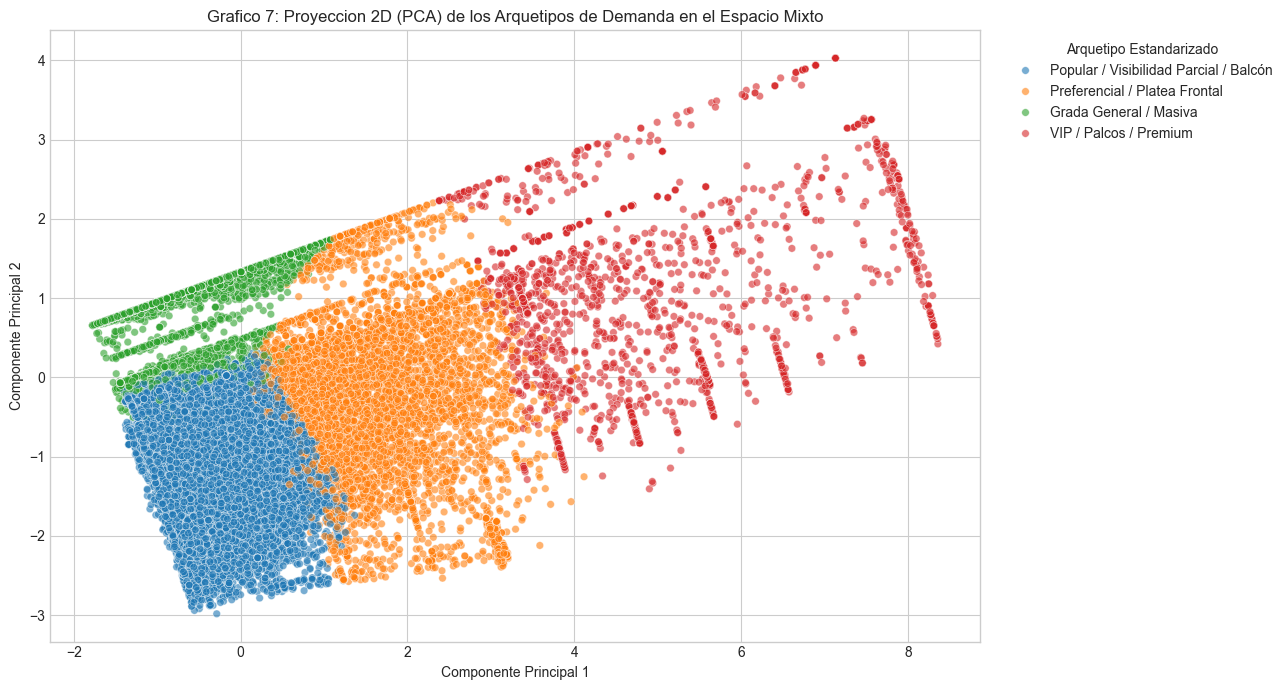

In [9]:
# Grafico 7: Proyeccion 2D en componentes principales PCA
plt.figure(figsize=(13, 7))
sns.scatterplot(
    data=df_final,
    x="pca_1",
    y="pca_2",
    hue="arquetipo_demanda",
    alpha=0.6,
    s=30,
    palette="tab10"
)
plt.title("Grafico 7: Proyeccion 2D (PCA) de los Arquetipos de Demanda en el Espacio Mixto")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.legend(title="Arquetipo Estandarizado", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Analisis del Grafico 7:
Las dos primeras componentes principales explican el **69.43% de la varianza total** del espacio mixto de 37 dimensiones. En el plano cartesiano, el grupo 'Grada General / Masiva' (17,182 registros) se ubica en el extremo derecho del componente principal 1, asociado a alto peso de aforo. El grupo 'VIP / Palcos / Premium' (1,919 registros) se concentra en una region densa y acotada impulsada por tags de palco/vip, ratios de precio elevados y alta tasa de ocupacion (69.7%). Los grupos 'Preferencial / Platea Frontal' (5,759 registros) y 'Popular / Visibilidad Parcial / Balcon' (9,018 registros) ocupan el espacio intermedio, separados verticalmente por el componente principal 2.

#### Conclusiones del Grafico 7:
1. **Representatividad de la Reduccion Dimensional:** Con casi el 70% de la informacion preservada en 2 ejes, se confirma que el espacio vectorial mixto sintetiza fielmente la estructura del catalogo.
2. **Cero Solapamiento Critico:** Los 4 arquetipos forman fronteras de decision coherentes sin mezclar zonas VIP con gradas generales.
3. **Clasificacion Automatica Robusta:** El modelo es capaz de clasificar con exito las 33,878 localidades en arquetipos estandarizados, listos para integrarse en tableros de Business Intelligence y reportes transversales de TuBoleta.

## 8. Validacion de Casos de Negocio: Separacion de Casos Complejos

In [10]:
# Validacion de casos de prueba del negocio
casos_test = df_final[
    df_final["logical_seat_category"].str.contains("ORO|PLATA|PALCO|VIP|PREFERENCIAL|GENERAL|BALCON|PLATEA", case=False, na=False)
][["product", "site", "logical_seat_category", "texto_limpio", "med_unit_amt_itx", "ratio_precio_max", "peso_aforo", "arquetipo_demanda"]]

print("Muestra de clasificacion de localidades complejas:")
display(casos_test.drop_duplicates(subset=["logical_seat_category", "arquetipo_demanda"]).head(15))

Muestra de clasificacion de localidades complejas:


,product,site,logical_seat_category,texto_limpio,med_unit_amt_itx,ratio_precio_max,peso_aforo,arquetipo_demanda
1,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,ESTADIO EL CAMPIN,PREFERENCIAL,PREFERENCIAL,505000.0,0.234339,0.214234,Popular / Visibilidad Parcial / Balcón
2,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,ESTADIO EL CAMPIN,VIP OCCIDENTAL,VIP OCCIDENTAL,845000.0,0.392111,0.087407,Popular / Visibilidad Parcial / Balcón
4,MAÑANA SERÁ BONITO LATAM TOUR KAROL G - 2DA FECHA,ESTADIO EL CAMPIN,VIP ORIENTAL,VIP ORIENTAL,845000.0,0.392111,0.085693,Popular / Visibilidad Parcial / Balcón
12,LLEGÓ EL PODER - BOGOTÁ - SILVESTRE DANGOND,ESTADIO EL CAMPIN,PALCOS EL REENCUENTRO,PALCOS,250000.0,0.416667,0.030904,Popular / Visibilidad Parcial / Balcón
13,FESTIVAL ÁFRICA EN BOGOTÁ 2024,TEATRO JORGE ELIECER GAITAN,PLATEA DELANTERA,PLATEA DELANTERA,67500.0,0.750000,0.394100,Preferencial / Platea Frontal
14,LLEGÓ EL PODER - BOGOTÁ - SILVESTRE DANGOND,ESTADIO EL CAMPIN,OCCIDENTAL ALTA VIP,OCCIDENTAL ALTA VIP,275000.0,0.458333,0.004496,Popular / Visibilidad Parcial / Balcón
15,SAINT SEIYA VS DRAGONBALL SINFÓNICO,TEATRO JORGE ELIECER GAITAN,PLATEA DELANTERA,PLATEA DELANTERA,230000.0,1.000000,0.394100,Popular / Visibilidad Parcial / Balcón
16,KEVIN KAARL - SEGUNDA FECHA,TEATRO JORGE ELIECER GAITAN,PALCO,PALCO,249000.0,0.925651,0.076970,Popular / Visibilidad Parcial / Balcón
20,CAMPESINOS,SALA 3 CINEMATECA,GENERAL,GENERAL,4895.0,1.000000,1.000000,Grada General / Masiva
21,LLEGÓ EL PODER - BOGOTÁ - SILVESTRE DANGOND,ESTADIO EL CAMPIN,PALCOS ENTRE GRANDES,PALCOS,240000.0,0.400000,0.070749,Popular / Visibilidad Parcial / Balcón


## 9. Guardado del Dataset Segmentado
Guardamos los resultados enriquecidos con su asignacion de cluster en `data/processed/localidades_clusterizadas.parquet`.

In [11]:
os.makedirs("../data/processed", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)

out_path = "../data/processed/localidades_clusterizadas.parquet" if os.path.exists("../data/processed") else "data/processed/localidades_clusterizadas.parquet"
df_final.to_parquet(out_path, index=False)
print(f"Dataset segmentado guardado exitosamente en: {out_path} ({os.path.getsize(out_path):,} bytes)")

Dataset segmentado guardado exitosamente en: ../data/processed/localidades_clusterizadas.parquet (2,816,225 bytes)
